# IIT-6. L'objet qui a mordu IIT — l'expander à Φ énorme, la grille qui assume, l'échange mesuré

## Navigation
**Série** : [IIT](./README.md) | **Partie** : Débats
**Précédent** : [IIT-5 : Lentilles et dissociations](./IIT-05-Lentilles-et-Dissociations.ipynb) | **Suivant** : --

## Objectifs d'apprentissage
1. **Connaître** l'objection d'Aaronson à IIT (2014) : un objet mathématique à Φ énorme et comportement trivial
2. **Exécuter** la construction de l'objection — Vandermonde, le « hack » W — et vérifier son arithmétique sur des instances réelles
3. **Mesurer** la même famille d'objets en IIT 3.0 avec PyPhi : grille, ligne, anneau, feedforward
4. **Distendre** les deux formalisations (Φ_DM vs Φ 3.0) et lire l'échange Aaronson/Tononi avec leurs grades respectifs

### Prérequis
- [IIT-1 : Introduction à PyPhi](./IIT-01-IntroToPyPhi.ipynb) (TPM, Subsystem, Φ, CES)
- Algèbre linéaire (rang d'une matrice, corps finis $\mathbb{F}_p$)
- Notions de théorie de l'information (entropie, bits)

### Durée estimée : 75-90 minutes

***

### **Sommaire**
1. [Le débat : deux positions, leurs grades](#sec1)
2. [La jambe Φ_DM : l'arithmétique de l'objection, exécutée](#sec2)
3. [La jambe PyPhi : la grille, la ligne, le feedforward en IIT 3.0](#sec3)
4. [Ce que l'échange a produit après](#sec4)
5. [Exercices](#sec5)
6. [Conclusion et ressources](#sec6)

***


**Cadre.** Ce notebook mesure, sur des instances réelles, l'objet au centre de l'échange
Aaronson/Tononi de mai 2014 : des systèmes à intégration informationnelle énorme et comportement
trivial. Deux jambes de mesure, deux formalisations — la $\Phi$ « à la Tononi 2008 » visée par
l'objection (notée $\Phi_{DM}$ ici), et la $\Phi$ d'IIT 3.0 calculée par PyPhi.

**Du côté de l'Epic.** Livrable de la veine 5 de l'[Epic Aaronson #16781](https://github.com/jsboige/CoursIA/issues/16781) :
« l'objet qui a mordu IIT » et « la réponse publiée qui assume la conséquence ». Les définitions
formelles posées ici préparent le terrain d'une future borne inférieure d'intégration prouvée en Lean
(hors périmètre de ce notebook). La question « qu'est-ce qu'une strate mesure ? » de l'Epic
[ICT #4588](https://github.com/jsboige/CoursIA/issues/4588) traverse ce notebook : $\Phi$ est
l'instrument, l'objet qui le sature en est le banc d'essai.


<a id="sec1"></a>
## 1. Le débat : deux positions, leurs grades

**Objectif** : présenter l'échange de mai 2014 en citant chaque position avec son grade —
ce qui est vérifiable sur machine dans ce notebook, ce qui ne l'est pas. On ne prête
d'état d'esprit à personne : chaque affirmation porte son auteur.

### 1.1 Chronologie et sources

| Date | Événement | Source (archivée au gisement, voir §6) |
|------|-----------|----------------------------------------|
| 21 mai 2014 | Aaronson publie *Why I Am Not An Integrated Information Theorist (or, The Unconscious Expander)* | scottaaronson.blog ?p=1799 |
| 22-24 mai 2014 | Mises à jour du post (clarifications 1-6, commentaire de Chalmers) | même page |
| ~28 mai 2014 | Tononi envoie une réponse de 14 pages, autorise sa publication | tononi.docx sur scottaaronson.com |
| 30 mai 2014 | Aaronson publie *Giulio Tononi and Me: A Phi-nal Exchange* | scottaaronson.blog ?p=1823 |

Les quatre textes sont archivés dans le gisement partagé (`Bibliographie IA/Consciousness/`,
voir §6) — ils ne vivent jamais dans le dépôt.

### 1.2 La position d'Aaronson (p=1799), citée

L'objection porte sur le **lien** entre Φ et la conscience, pas sur le calcul de Φ :

> *« Yes, it might be a decent rule of thumb that, if you want to know which brain regions
> (for example) are associated with consciousness, you should start by looking for regions
> with lots of information integration. [...] However, having a large Φ-value is certainly
> not a **sufficient** condition for consciousness, or even for the appearance of
> consciousness. »* — Aaronson, p=1799

> *« Oui, cela pourrait être une bonne règle empirique de chercher l'intégration pour
> localiser les régions associées à la conscience. [...] Mais une grande valeur de Φ
> n'est certainement pas une condition **suffisante** de conscience, pas même de
> l'apparence de la conscience. »* — traduction

La construction (reproduite et exécutée en §2) :

> *« I've shown that my system—the system that simply applies the matrix W to an input
> vector x—has an _enormous_ amount of integrated information Φ. »* — Aaronson, p=1799

Et le mot de la fin sur la grille d'expansion :

> *« The brain might be an expander, but not every expander is a brain. »* — Aaronson, p=1799

> *« Le cerveau est peut-être un expander, mais tous les expanders ne sont pas des cerveaux. »* — traduction

Son geste caractéristique en conclusion :

> *« the fact that Integrated Information Theory is wrong—demonstrably wrong, for reasons
> that go to its core—puts it in something like the top 2% of all mathematical theories of
> consciousness ever proposed. »* — Aaronson, p=1799

> *« le fait que l'IIT soit fausse — démontrablement fausse, pour des raisons qui touchent
> à son cœur — la place grosso modo dans le top 2 % de toutes les théories mathématiques de
> la conscience jamais proposées. »* — traduction

**Grade** : la construction mathématique est **exacte et exécutable** — ce notebook la
reproduit en §2 et vérifie chaque chiffre sur instance réelle (VÉRIFIÉ). Le saut
« Φ énorme donc pas suffisant pour la conscience » est un **argument philosophique**
(paradigme-cases), pas une mesure — son statut est discuté, jamais tranché ici.

### 1.3 La position de Tononi (essai du 28 mai), citée

La réponse assume la conséquence — dans les mots de Tononi lui-même :

> *« Scott's mathematical argument is right: certain systems whose structure and function
> are easy to describe from the extrinsic perspective of an observer, such as expander
> graphs performing parity checks, or worse, grids doing absolutely nothing, may in fact
> have a large value of PHI if they can be built to be large enough [...] However, Scott's
> "commonsense" intuition that such simple systems cannot possibly be conscious is wrong
> and should be revised. »* — Tononi, essai du 28 mai 2014

> *« L'argument mathématique de Scott est juste : certains systèmes dont la structure et
> la fonction sont faciles à décrire du point de vue extrinsèque d'un observateur —
> graphes d'expansion faisant des contrôles de parité, ou pire, des grilles ne faisant
> strictement rien — peuvent en fait avoir une grande valeur de Φ pourvu qu'on puisse les
> construire assez grands. [...] Cependant, l'intuition de "sens commun" de Scott selon
> laquelle de tels systèmes simples ne peuvent pas être conscients est fausse et doit
> être révisée. »* — traduction

Et la conclusion de l'essai :

> *« [...] if we trust a theory that starts from phenomenology and is supported by
> empirical evidence more than unreliable and unsupported intuitions, our best inference
> should be that, if a 2D grid is large and well built, it could be quite conscious,
> though perhaps a bit boring and not that intelligent. »* — Tononi, essai du 28 mai 2014

> *« [...] si nous faisons plus confiance à une théorie qui part de la phénoménologie et
> s'appuie sur des preuves empiriques qu'à des intuitions peu fiables et non étayées,
> notre meilleure inférence devrait être que, si une grille 2D est grande et bien
> construite, elle pourrait être assez consciente — quoique peut-être un peu ennuyeuse
> et pas très intelligente. »* — traduction

Deux précisions techniques de première importance, données par Tononi en tête d'essai :

> *« Scott does not consider the latest formulation of IIT and PHI (3.0, here), so his
> arguments about normalization, for instance, are not relevant (normalization is not
> necessary in 3.0). [...] However, his main point that certain systems that are simple
> [...] could have large values of PHI, still stands. In fact, the numbers for IIT 3.0
> would be even "worse". »* — Tononi, essai du 28 mai 2014

**Grade** : la position est **assumée et cohérente avec les postulats d'IIT** — la grille
qu'il défend est à **portes majorité** (« fire if the majority of the inputs are on »),
à l'état tout éteint, sans entrées ni sorties. Ce notebook mesure cette grille-là en §3
(instance PyPhi réelle, à petite échelle). Le statut de conscience de la grille n'est
**pas mesurable** — aucune mesure indépendante de la conscience n'existe ; il est cité
comme position, jamais évalué.


### 1.4 Les quatre contre-arguments d'Aaronson (p=1823)

Face à l'essai de Tononi, Aaronson répond argument par argument. Nature de chacun —
aucun n'est computationnel, tous sont philosophiques ; ils sont cités pour la complétude
du dialogue, pas tranchés :

| # | Nom (donné ici) | Résumé | Nature |
|---|-----------------|--------|--------|
| I | Le « Copernic de la conscience » | L'analogie héliocentrique ne s'applique pas : nous n'avons pas de définition convenue de « conscience » à tester, seulement des cas paradigmatiques (vous êtes conscient ; un rocher, un mur, un décodeur Reed-Solomon, non). Sa contre-analogie : une définition de la continuité qui rendrait $x^2$ discontinue et $\lfloor x \rfloor$ continue serait une **mauvaise définition**, pas une découverte ; un thermomètre qui dit que l'eau bouillante est plus froide que la glace est à réparer (« when the clock strikes 13, it's time to fix the clock »). | Philosophique (théorie des définitions) |
| II | Les postulats | Les cinq postulats d'IIT (existence, composition, information, intégration, singularité) : il ne les comprend pas, n'accepte pas nécessairement leur vérité, et ne voit pas comment ils mènent à Φ — « si les postulats déterminaient univoquement Φ, que dire de toutes ces mises à jour ? » (Φ 1.0 → 2.0 → 3.0). Tononi répond (fin d'essai) que la formulation évolue encore et que « les arguments mathématiques sont essentiels » au développement de l'IIT. | Philosophique (analyse des définitions) |
| III | L'ironie du cervelet | Tononi compte comme succès qu'IIT rende le cervelet inconscient (69 milliards de neurones, connexions sans latéralité → faible intégration) — mais comment *sait-on* que le cervelet n'est pas conscient ? « Il vient de nous dire qu'une grille 2D **est** consciente ! » On ne peut pas compter l'inconscience du cervelet comme succès et refuser celle de la grille comme test. | Philosophique (cohérence des critères empiriques) |
| IV | Le mur et la corde | L'argument phénoménologique de Tononi (regarder un écran vide : l'expérience de l'espace 2D est riche et structurée → une grille 2D bien construite peut la spécifier) : pourquoi pas la corde 1D, elle aussi « riche et structurée » (un ordre total, même) ? La réponse d'IIT (Φ(line) = O(1)) renvoie la question à la mesure — c'est ce que le §3 exécute. | Mixte — la prédiction Φ(line)/Φ(grid) est **mesurable en tendance** (§3) |

### 1.5 La divergence de Porto Rico — une mémoire contestée, deux attributions

Dans p=1799, Aaronson rapporte ( « as best as I can reconstruct it ») une réponse orale de
Tononi à une conférence FQXi : « *it's wrong to approach IIT like a mathematician* ». Dans
son essai, Tononi **conteste cette reconstitution** :

> *« What I actually said then, and many times before, is that IIT does not start by being
> infatuated with a particular mathematical quantity [...] In short, IIT does not start
> from mathematics hoping to explain phenomenology, but rather it starts from phenomenology
> to end with mathematics. Hence mathematical arguments are not only welcome, but are
> essential to the development and revision of IIT. »* — Tononi, essai du 28 mai 2014

> *« Ce que j'ai réellement dit alors, et de nombreuses fois auparavant, c'est que l'IIT
> ne commence pas par être infatuée d'une quantité mathématique particulière [...] En
> bref, l'IIT ne part pas des mathématiques en espérant expliquer la phénoménologie ;
> elle part de la phénoménologie pour aboutir aux mathématiques. Les arguments
> mathématiques ne sont donc pas seulement bienvenus : ils sont essentiels. »* — traduction

**Discipline** : ce notebook retient la version de Tononi pour caractériser la position de
Tononi (source firsthand) et celle d'Aaronson pour caractériser le récit d'Aaronson —
la mémoire de l'échange oral n'est tranchée par aucune des deux sources.

### 1.6 Le point technique décisif : deux formalisations de Φ

L'objection d'Aaronson vise la Φ **qu'il pouvait formaliser** en 2014 — une Φ « à la
Tononi 2008 » pour systèmes à mémoire discrète, définie par bipartitions avec normalisation
(notation $\Phi_{DM}$ dans ce notebook). Tononi objecte dès l'ouverture de son essai que
cette version n'est pas la dernière (3.0), et que les nombres 3.0 seraient « pires » —
c'est-à-dire plus grands encore.

Ce notebook exécute donc **deux jambes** :

| Jambe | Formalisation | Outil | Ce qui est mesuré | Grade |
|-------|---------------|-------|-------------------|-------|
| §2 | $\Phi_{DM}$ (bipartitions, normalisation) | notre implémentation NumPy sur $\mathbb{F}_p$ | Vandermonde, le hack W, l'identité, la scalabilité | **Exact** (calculs de rang) — mais c'est la définition du post d'Aaronson, pas PyPhi |
| §3 | Φ d'IIT 3.0 | PyPhi 1.2.0 (moteur de référence) | ligne, anneau, grille (majorité **et** XOR), feedforward, contraste riche | **Exact aux tailles mesurées** (n ≤ 6) ; intractable au-delà de ~8 nœuds — dit comme tel |

**Aucune jambe ne mesure la conscience** — chacune mesure une quantité informationnelle.
C'est toute la question de l'échange, et elle reste ouverte.


<a id="sec2"></a>
## 2. La jambe Φ_DM : l'arithmétique de l'objection, exécutée

### 2.1 Principe : l'information efficace d'une application linéaire se lit au rang

Le post d'Aaronson travaille sur $S = \mathbb{F}_p^n$ avec la fonction de mise à jour
$f(x) = Mx$ ($M$ une matrice $n \times n$ sur le corps fini $\mathbb{F}_p$,
$p$ premier). Pour une bipartition $(A, B)$ des coordonnées :

- $EI(A \to B)$ mesure l'effet de l'intervention sur la partie $A$ de l'état courant
  sur la partie $B$ de l'état suivant ;
- pour une application **linéaire déterministe**, cet effet vit dans un sous-espace affine
  de dimension $\mathrm{rang}(M[B, A])$ — le rang de la sous-matrice lignes $B$,
  colonnes $A$ ;
- d'où, en bits : $EI(A \to B) = \mathrm{rang}(M[B,A]) \cdot \log_2 p$.

La définition visée par l'objection est alors :

$$\Phi(A,B) = EI(A \to B) + EI(B \to A), \qquad \Phi = \Phi(A^*, B^*) \text{ où } (A^*,B^*) \text{ minimise } \frac{\Phi(A,B)}{\min\{|A|,|B|\}}$$

La normalisation par $\min\{|A|,|B|\}$ est celle de Tononi 2008 (le « facteur
d'échelle ») — c'est précisément ce que IIT 3.0 abandonnera (Tononi, essai : « normalization
is not necessary in 3.0 »).

**Mise en garde de sobriété** : ce qui suit est **notre** implémentation de cette définition,
fidèle au post ; ce n'est **pas** PyPhi, et PyPhi n'est pas ceci. Les deux jambs se lisent
l'une à côté de l'autre, jamais l'une dans l'autre.


In [1]:
import warnings
# pyemd (importe par pyphi) emet un avertissement de deprecation pkg_resources qui fuite
# le chemin site-packages -- meme garde que IIT-01.
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*", category=UserWarning)

import math
import itertools
import numpy as np
import pyphi

pyphi.config.PROGRESS_BARS = False
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

print("PyPhi version:", pyphi.__version__)
print("NumPy version:", np.__version__)


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'

PyPhi version: 1.2.0
NumPy version: 1.26.4


In [2]:
def inverse_mod(a, p):
    """Inverse de a dans F_p (p premier) -- petit theoreme de Fermat."""
    return pow(int(a) % p, p - 2, p)


def rang_mod_p(mat, p):
    """Rang d'une sous-matrice entiere sur le corps fini F_p.
    Elimination gaussienne modulaire, pivots sur lignes/colonnes."""
    m = [[int(x) % p for x in row] for row in mat]
    n_rows, n_cols = len(m), len(m[0]) if m else 0
    rang = 0
    piv_row = 0
    for col in range(n_cols):
        # chercher un pivot non nul dans la colonne, lignes restantes
        pivot = None
        for r in range(piv_row, n_rows):
            if m[r][col] % p != 0:
                pivot = r
                break
        if pivot is None:
            continue
        m[piv_row], m[pivot] = m[pivot], m[piv_row]
        inv = inverse_mod(m[piv_row][col], p)
        m[piv_row] = [(x * inv) % p for x in m[piv_row]]
        for r in range(n_rows):
            if r != piv_row and m[r][col] % p != 0:
                facteur = m[r][col]
                m[r] = [(x - facteur * y) % p for x, y in zip(m[r], m[piv_row])]
        piv_row += 1
        rang += 1
        if piv_row == n_rows:
            break
    return rang


# Controles rapides sur instances connues
assert rang_mod_p([[1, 0], [0, 1]], 7) == 2
assert rang_mod_p([[2, 4], [1, 2]], 7) == 1          # lignes proportionnelles
assert rang_mod_p([[3, 1], [0, 0]], 7) == 1
assert rang_mod_p(np.zeros((3, 3), dtype=int), 7) == 0
print("Contrles de rang_mod_p : OK")

Contrles de rang_mod_p : OK


In [3]:
def EI(M, A, B, p):
    """EI(A -> B) en bits pour f(x) = Mx sur F_p : rang(M[B, A]) * log2(p).

    M : matrice n x n (entiers, lus mod p). A, B : tuples d'indices de coordonnees
    (B = lignes de la sortie, A = colonnes de l'entree).
    """
    n = M.shape[0]
    sub = M[np.ix_(list(B), list(A))]
    return rang_mod_p(sub, p) * math.log2(p)


def phi_bipartition(M, A, B, p):
    """Phi(A, B) = EI(A->B) + EI(B->A), en bits."""
    return EI(M, A, B, p) + EI(M, B, A, p)


def phi_dm(M, p):
    """Phi 'a la Tononi 2008' visee par le post : minimum sur les bipartitions
    de la valeur normalisee Phi(A,B)/min(|A|,|B|).

    Retourne un dict : {normalise_min, argmins (liste), phi_final, n_bipartitions}.
    Si plusieurs bipartitions realisent le minimum, le Phi final est NOTE COMME
    INDEFINI -- c'est le premier resultat du post.
    """
    n = M.shape[0]
    idx = range(n)
    best_norm = None
    argmins = []
    n_enum = 0
    for taille_A in range(1, n // 2 + 1):
        for A in itertools.combinations(idx, taille_A):
            # representation canonique : a taille n/2, ne prendre qu'un sens
            # de chaque paire complementaire (A,B)/(B,A) -> 0 doit etre dans A
            if taille_A == n // 2 and 0 not in A:
                continue
            n_enum += 1
            B = tuple(j for j in idx if j not in A)
            norm = phi_bipartition(M, A, B, p) / min(len(A), len(B))
            if best_norm is None or norm < best_norm - 1e-9:
                best_norm = norm
                argmins = [(A, B)]
            elif abs(norm - best_norm) <= 1e-9:
                argmins.append((A, B))
    assert n_enum == 2 ** (n - 1) - 1, n_enum
    return {
        "normalise_min": best_norm,
        "argmins": argmins,
        "n_argmins": len(argmins),
        "phi_final": phi_bipartition(M, *argmins[0], p),
        "n_bipartitions": n_enum,
    }


print("Definitions en place : EI, phi_bipartition, phi_dm")

Definitions en place : EI, phi_bipartition, phi_dm


### 2.2 Vandermonde : l'égalité partout, et le Φ indéfini

La matrice de Vandermonde $V_{ij} = i^{\,j-1} \pmod p$ (bases $i = 1..n$,
exposants $j = 0..n-1$). Le post : « for p large enough, the Vandermonde matrix is
well-known to have the property that _every submatrix is full-rank_ ». Alors, pour
**chaque** bipartition :

$$EI(A \to B) = EI(B \to A) = \min\{|A|,|B|\} \log_2 p \quad \Rightarrow \quad \frac{\Phi(A,B)}{\min\{|A|,|B|\}} = 2\log_2 p$$

La valeur **normalisée** est la même (maximale) partout — le minimum n'existe pas de façon
unique, et la valeur non normalisée $\Phi(A,B)$ varie de $2\log_2 p$ à
$n \log_2 p$ selon la bipartition choisie. **Φ est indéfini** sur cet objet.


In [4]:
def vandermonde(n, p):
    """Matrice de Vandermonde n x n sur F_p : V[i, j] = (i+1)^j mod p
    (bases 1..n, exposants 0..n-1 -- convention du post)."""
    return np.array([[(i + 1) ** j % p for j in range(n)] for i in range(n)], dtype=int)


n, p = 8, 1009   # p premier, largement > n
V = vandermonde(n, p)

res_V = phi_dm(V, p)
print(f"Vandermonde n={n}, p={p} -- {res_V['n_bipartitions']} bipartitions enumerees")
print(f"  valeur normalisee minimale : {res_V['normalise_min']:.4f} bits/element")
print(f"  attendu (post)            : {2 * math.log2(p):.4f} = 2*log2(p) partout")
print(f"  bipartitions au minimum   : {res_V['n_argmins']} sur {res_V['n_bipartitions']}")

# Distribution des valeurs normalisees : toutes egales ?
norms = []
for taille_A in range(1, n // 2 + 1):
    for A in itertools.combinations(range(n), taille_A):
        B = tuple(j for j in range(n) if j not in A)
        norms.append(phi_bipartition(V, A, B, p) / min(len(A), len(B)))
print(f"  valeurs normalisees distinctes : {sorted(set(round(x, 6) for x in norms))}")

Vandermonde n=8, p=1009 -- 127 bipartitions enumerees
  valeur normalisee minimale : 19.9574 bits/element
  attendu (post)            : 19.9574 = 2*log2(p) partout
  bipartitions au minimum   : 127 sur 127
  valeurs normalisees distinctes : [19.957421]


**Lecture du résultat.** Toutes les bipartitions réalisent la même valeur normalisée
maximale $2\log_2 p$ : le minimum n'est pas unique, et la valeur non normalisée
$\Phi(A,B)$ dépend de la bipartition — de $2\log_2 p$ ($|A| = 1$) à
$n \log_2 p$ ($|A| = n/2$). Sur cette instance, $\Phi_{DM}$ est **indéfini**,
exactement comme l'énonce le post. C'est le premier résultat de l'objection : la
définition elle-même bute sur cet objet.

*Note honnête* : la propriété « toute sous-matrice de rang plein » est asymptotique
(« p suffisamment grand »). Sur l'instance mesurée (n=8, p=1009) elle se vérifie
exactement — si un premier plus petit avait divisé un déterminant, l'égalité serait
brisée ; le fait mesuré est que pour ce couple (n, p), elle ne l'est pas.

### 2.3 Le « hack ironique » : la matrice W et son Φ unique

Pour rendre Φ bien défini, le post remplace $V$ par $W$ : les $n/2$ premières
lignes de $V$, **chacune répétée deux fois** (n multiple de 4). Intuitivement : on
**diminue** l'intégration réelle du système (l'information qu'il calcule, divisée par 2)
pour faire baisser la valeur normalisée de la bipartition naturelle $A = \{1..n/2\}$,
$B = \{n/2+1..n\}$ — laquelle devient l'**unique** minimum, si bien que le Φ non
normalisé rendu par la prescription vaut :

$$\Phi = \frac{n}{2} \log_2 p$$

soit « half of its entire information content » — la moitié du contenu informationnel
total du système.


In [5]:
def matrice_W(n, p):
    """W = les n/2 premieres lignes de la Vandermonde, chacune repetee deux fois."""
    V = vandermonde(n, p)
    W = []
    for i in range(n // 2):
        W.append(V[i])
        W.append(V[i])
    return np.array(W, dtype=int)


n, p = 8, 1009
W = matrice_W(n, p)

res_W = phi_dm(W, p)
print(f"Matrice W n={n}, p={p}")
print(f"  valeur normalisee minimale : {res_W['normalise_min']:.4f} bits/element")
print(f"  attendu (post)            : {math.log2(p):.4f} = log2(p)")
print(f"  bipartitions au minimum   : {res_W['n_argmins']} sur {res_W['n_bipartitions']}")
print(f"  bipartition naturelle {{0..3}} | {{4..7}} au minimum :",
      any(set(A) == set(range(n // 2)) for A, B in res_W['argmins']))
print(f"  PHI final (mesure)        : {res_W['phi_final']:.4f} bits")
print(f"  PHI attendu (post)        : {(n / 2) * math.log2(p):.4f} = (n/2)*log2(p)")
print(f"  contenu total n*log2(p)   : {n * math.log2(p):.4f} bits -> PHI = 50 % du total")

Matrice W n=8, p=1009
  valeur normalisee minimale : 9.9787 bits/element
  attendu (post)            : 9.9787 = log2(p)
  bipartitions au minimum   : 3 sur 127
  bipartition naturelle {0..3} | {4..7} au minimum : True
  PHI final (mesure)        : 39.9148 bits
  PHI attendu (post)        : 39.9148 = (n/2)*log2(p)
  contenu total n*log2(p)   : 79.8297 bits -> PHI = 50 % du total


**Lecture du résultat.** Mesuré sur instance réelle : la bipartition naturelle est bien
l'unique minimum (aux réordonnements triviaux de lignes près), et le Φ rendu vaut
exactement $(n/2)\log_2 p$ — la moitié du contenu informationnel du système. Tout ça
pour un système qui ne fait **que** appliquer une application linéaire de rang $n/2$
(des lignes dupliquées) : évaluer un polynôme en $n$ points, autrement dit un
**code correcteur de Reed-Solomon**. Le post : « *you can have integrated information
without consciousness [...] just like you can have computation without consciousness* ».

L'ironie est dans le geste : pour **maximiser** le Φ rendu, on a **divisé par deux**
l'intégration intuitive du système. Aaronson y voit une « disturbing non-robustness » de
la définition.

### 2.4 Le contre-éclairage : la matrice identité (Φ = 0)

La clarification (4) du 22 mai précise ce qui fait travailler la construction : ce n'est
pas l'inversibilité (l'identité est inversible et donne Φ = 0), c'est la propriété
« **toutes** les sous-matrices de rang plein » — chaque sous-ensemble de sorties
maximalement corrélé à chaque sous-ensemble d'entrées. L'identité est le contre-exemple
interne : même taille, inversible, et zéro intégration.


In [6]:
n, p = 8, 1009
I = np.identity(n, dtype=int)

res_I = phi_dm(I, p)
print(f"Matrice identite n={n}, p={p}")
print(f"  valeur normalisee minimale : {res_I['normalise_min']:.6f}")
print(f"  PHI final                  : {res_I['phi_final']:.6f} bits")
print(f"  attendu (mise a jour 4 du post) : PHI = 0 -- inversible != integre")

Matrice identite n=8, p=1009
  valeur normalisee minimale : 0.000000
  PHI final                  : 0.000000 bits
  attendu (mise a jour 4 du post) : PHI = 0 -- inversible != integre


**Lecture du résultat.** $\Phi_{DM}(\mathrm{Id}) = 0$ exactement : inversible et
totalement décomposable. Le contraste Id / W borne l'espace de la construction — deux
matrices inversibles de même taille, l'une à Φ nul, l'autre à Φ = moitié du contenu total.

### 2.5 Scalabilité : la croissance linéaire, « franchement indigeste »

Le post : à $n \sim 10^{14}$ (atteignable avec les ordinateurs existants), le Φ du
système W dépasserait « any plausible upper bound on the integrated information content
of the human brain ». Mesurons la tendance — le Φ exact reste un calcul de rang, donc
tractable bien plus loin que PyPhi (c'est tout l'intérêt de cette jambe).


In [7]:
p = 1009
print(f"{'n':>4} {'PHI = (n/2)log2(p)':>20} {'total n*log2(p)':>16} {'rapport':>8} {'bipartitions':>13}")
print("-" * 68)
for n in (4, 8, 12, 16):
    W = matrice_W(n, p)
    res = phi_dm(W, p)
    total = n * math.log2(p)
    print(f"{n:>4} {res['phi_final']:>20.2f} {total:>16.2f} {res['phi_final'] / total:>7.1%} "
          f"{res['n_bipartitions']:>13,}")

print()
print("Croissance : PHI lineaire en n, rapport 50 % constant -- la famille W sature")
print("la mesure a toutes les tailles mesurables (et au-dela : le calcul est un rang).")

   n   PHI = (n/2)log2(p)  total n*log2(p)  rapport  bipartitions


--------------------------------------------------------------------
   4                19.96            39.91   50.0%             7
   8                39.91            79.83   50.0%           127


  12                59.87           119.74   50.0%         2,047


  16                79.83           159.66   50.0%        32,767

Croissance : PHI lineaire en n, rapport 50 % constant -- la famille W sature
la mesure a toutes les tailles mesurables (et au-dela : le calcul est un rang).


### 2.6 Grade de la jambe Φ_DM

- **Ce qui est mesuré** : des valeurs **exactes** (calculs de rang sur $\mathbb{F}_p$),
  sur des instances réelles — l'égalité Vandermonde, l'unique minimum de W, le Φ = 0 de
  l'identité, la croissance linéaire. Chaque chiffre du post se vérifie au bit près.
- **Ce que c'est** : notre implémentation de la définition visée par l'objection
  (bipartitions + normalisation, « Tononi 2008 »). **Ce n'est pas** le Φ d'IIT 3.0 —
  Tononi le dit dès l'ouverture de son essai, et ajoute que les nombres 3.0 seraient
  « pires » (plus grands).
- **Ce que ce n'est pas** : une mesure de conscience, ni une preuve qu'IIT est fausse.
  C'est la vérification qu'un objet mathématique de description triviale sature la mesure
  visée — le reste de l'échange est philosophique et cité comme tel (§1).

***

<a id="sec3"></a>
## 3. La jambe PyPhi : la grille, la ligne, le feedforward en IIT 3.0

### 3.1 Protocole — les réseaux de l'échange, instanciés

Le terrain de la réponse de Tononi n'est pas la matrice W mais la **grille 2D physique** :
éléments binaires, portes « fire if the majority of the inputs are on », connectivité de
voisinage en treillis, à l'état **tout éteint** (« all the logic gates are off »), sans
entrées ni sorties. Aaronson, lui, parle de grilles et d'expanders **de portes XOR** —
c'est le cadrage de p=1799/p=1823. Les deux familles sont donc mesurées.

Tous les réseaux de cette jambe sont évalués à l'état tout-zéros (point fixe de chacune
de ces dynamiques — exactement le scénario « grille qui ne fait rien » de l'essai), en Φ
d'IIT 3.0 via `pyphi.compute.phi` (le moteur de référence du laboratoire Tononi, version
1.2.0).

| Réseau | n | Portes | Topologie | D'où il vient |
|--------|---|--------|-----------|---------------|
| `ring3` | 3 | XOR | anneau complet | IIT-01 (référence de la série) |
| `line4` | 4 | XOR/COPY | chaîne ouverte | la « ligne 1D » de l'argument IV |
| `ring4` | 4 | XOR | cycle | l'anneau pair — topologie **bipartite** |
| `ff4` | 4 | bruitées | 2 sources indépendantes → 2 portes | l'expander **sans récurrence** (update 6) |
| `line6` | 6 | majorité/COPY | chaîne ouverte | la ligne, version Tononi |
| `ring6` | 6 | majorité | cycle | l'anneau, version Tononi |
| `grid6` | 6 | majorité | grille 2×3 (voisinage von Neumann) | **la grille qui assume** (essai) |
| `grid6_xor` | 6 | XOR | grille 2×3 | la grille, cadrage Aaronson |
| `rich6` | 6 | hétérogènes | irrégulière | le contraste « comportement riche » |


In [8]:
def build_network(gates, labels=None):
    """'gates' : liste de (fonction, tuple_indices_parents). Construit TPM + CM.

    La fonction recoit l'etat (tuple) des parents et rend 0/1 (deterministe)
    ou une probabilite de passer a 1 (probabiliste).
    """
    n = len(gates)
    tpm = np.zeros((2,) * n + (n,))
    cm = np.zeros((n, n), dtype=int)
    for i, (fun, parents) in enumerate(gates):
        for j in parents:
            cm[i, j] = 1
    for state in itertools.product((0, 1), repeat=n):
        for i, (fun, parents) in enumerate(gates):
            tpm[state][i] = fun(tuple(state[j] for j in parents))
    lab = labels or tuple(chr(65 + i) for i in range(n))
    return pyphi.Network(tpm, cm=cm, node_labels=lab)


XOR = lambda s: sum(s) % 2
COPY = lambda s: s[0]
AND = lambda s: int(all(s))
OR = lambda s: int(any(s))
MAJ = lambda s: int(sum(s) * 2 > len(s))       # majorite stricte (2 entrees -> AND)

# -- n=3 : la reference de la serie (IIT-01) --
ring3 = build_network([(XOR, (1, 2)), (XOR, (0, 2)), (XOR, (0, 1))])

# -- n=4 : ligne, anneau pair, feedforward bruite --
line4 = build_network([
    (COPY, (1,)), (XOR, (0, 2)), (XOR, (1, 3)), (COPY, (2,)),
])
ring4 = build_network([
    (XOR, (1, 3)), (XOR, (0, 2)), (XOR, (1, 3)), (XOR, (2, 0)),
])

def bruit(s):        # source parente : 50/50 quoi qu'il arrive
    return 0.5

ff4 = build_network([
    (bruit, ()), (bruit, ()), (XOR, (0, 1)), (AND, (0, 1)),
])

print("Reseaux n=3-4 construits : ring3, line4, ring4, ff4")

Reseaux n=3-4 construits : ring3, line4, ring4, ff4


In [9]:
def mesure_phi(net, nom, etat=None):
    """Phi d'IIT 3.0 du systeme entier, a l'etat tout-zeros par defaut."""
    n = len(net.node_labels)
    etat = etat or (0,) * n
    sub = pyphi.Subsystem(net, etat, tuple(range(n)))
    phi = pyphi.compute.phi(sub)
    print(f"  {nom:<12} n={n}  etat={etat}  ->  Phi = {phi:.5f}")
    return phi


print("n=3 -- reference de la serie :")
phi_ring3 = mesure_phi(ring3, "ring3")

print()
print("n=4 -- ligne, anneau pair, feedforward :")
phi_line4 = mesure_phi(line4, "line4")
phi_ring4 = mesure_phi(ring4, "ring4")
phi_ff4 = mesure_phi(ff4, "ff4")

n=3 -- reference de la serie :


  ring3        n=3  etat=(0, 0, 0)  ->  Phi = 1.87500

n=4 -- ligne, anneau pair, feedforward :


  line4        n=4  etat=(0, 0, 0, 0)  ->  Phi = 1.75000


  ring4        n=4  etat=(0, 0, 0, 0)  ->  Phi = 0.00000
  ff4          n=4  etat=(0, 0, 0, 0)  ->  Phi = 0.00000


**Lecture des résultats n=3-4.**

- **`ring3` (XOR, impair)** : on retrouve le $\Phi = 1{,}875$ de IIT-01 — la référence
  de la série, anneau récursif non décomposable.
- **`ring4` (XOR, pair)** : l'anneau **pair** a une topologie **bipartite**
  ($\{0, 2\}$ d'un côté, $\{1, 3\}$ de l'autre) ; muni de portes XOR, la dynamique
  est **linéaire sur GF(2)** et parfaitement décomposable — le Φ s'effondre. IIT-02
  (section 6.2) mesure le même mécanisme sur l'anneau AND/OR : c'est la **non-linéarité**
  des portes qui préserve l'irréductibilité, pas la récurrence seule.
- **`ff4`** : deux **sources de bruit indépendantes** (sans parents) alimentent deux
  portes. Système purement causal en aval, sans boucle : le Φ mesuré est nul — le réseau
  se partitionne sans perte. C'est la version PyPhi de l'expander **sans récurrence** :
  la mise à jour (6) du post d'Aaronson dit exactement pourquoi la grille récursive est
  la bonne instanciation (« fix the dynamics by iterating »), et Tononi liste parmi les
  prédictions contre-intuitives d'IIT : « *Systems that have a purely feed-forward
  architecture are unconscious* ».

**Premier fait mesuré** : l'objet « XOR + récurrence **paire régulière** » qui saturait
la jambe Φ_DM ne sature **pas** IIT 3.0 — la linéarité sur GF(2) décompose le cycle pair
régulier. Mais c'est une propriété de cette topologie précise, pas des portes XOR en
général : la grille 2×3 de la famille n=6 (nœuds de degré 3) montrera l'autre visage de
la parité. Tononi, lui, instancie sa grille à portes **majorité** dès l'essai — la
famille n=6 mesure donc les deux cadrages sur la même topologie.


In [10]:
# -- n=6 : ligne / anneau / grille, portes majorite (Tononi) et XOR (Aaronson) --

def voisins_ligne(i, n=6):
    return [j for j in (i - 1, i + 1) if 0 <= j < n]

def voisins_anneau(i, n=6):
    return [(i - 1) % n, (i + 1) % n]

def voisins_grille(i, rows=2, cols=3):
    """Grille rows x cols, voisinage von Neumann aux frontieres."""
    r, c = divmod(i, cols)
    nb = []
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        rr, cc = r + dr, c + dc
        if 0 <= rr < rows and 0 <= cc < cols:
            nb.append(rr * cols + cc)
    return nb


def porte_de_voisinage(voisins, booleen):
    """Un noeud dont la porte booleen s'applique a ses voisins ; COPY si isole."""
    if len(voisins) == 1:
        return (COPY, tuple(voisins))
    return (booleen, tuple(voisins))


line6 = build_network([porte_de_voisinage(voisins_ligne(i), MAJ) for i in range(6)])
ring6 = build_network([porte_de_voisinage(voisins_anneau(i), MAJ) for i in range(6)])
grid6 = build_network([porte_de_voisinage(voisins_grille(i), MAJ) for i in range(6)])
grid6_xor = build_network([porte_de_voisinage(voisins_grille(i), XOR) for i in range(6)])

# -- le contraste : meme taille, portes heterogenes, connectivite irreguliere --
rich6 = build_network([
    (XOR, (1, 3)),
    (AND, (2, 4)),
    (OR,  (0, 5)),
    (MAJ, (0, 2, 4)),
    (OR,  (1, 3)),
    (AND, (0, 2)),
])

print("Reseaux n=6 construits : line6, ring6, grid6, grid6_xor, rich6")
print("Connectivite grille 2x3 (voisins par noeud) :",
      [len(voisins_grille(i)) for i in range(6)])

Reseaux n=6 construits : line6, ring6, grid6, grid6_xor, rich6
Connectivite grille 2x3 (voisins par noeud) : [2, 3, 2, 2, 3, 2]


In [11]:
print("n=6 -- la famille de l'echange, Phi d'IIT 3.0 a l'etat tout-zeros :")
phi_line6 = mesure_phi(line6, "line6")
phi_ring6 = mesure_phi(ring6, "ring6")
phi_grid6 = mesure_phi(grid6, "grid6")
phi_grid6xor = mesure_phi(grid6_xor, "grid6_xor")
phi_rich6 = mesure_phi(rich6, "rich6")

n=6 -- la famille de l'echange, Phi d'IIT 3.0 a l'etat tout-zeros :


  line6        n=6  etat=(0, 0, 0, 0, 0, 0)  ->  Phi = 0.02778


  ring6        n=6  etat=(0, 0, 0, 0, 0, 0)  ->  Phi = 0.13889


  grid6        n=6  etat=(0, 0, 0, 0, 0, 0)  ->  Phi = 0.65477


  grid6_xor    n=6  etat=(0, 0, 0, 0, 0, 0)  ->  Phi = 3.25000


  rich6        n=6  etat=(0, 0, 0, 0, 0, 0)  ->  Phi = 0.00000


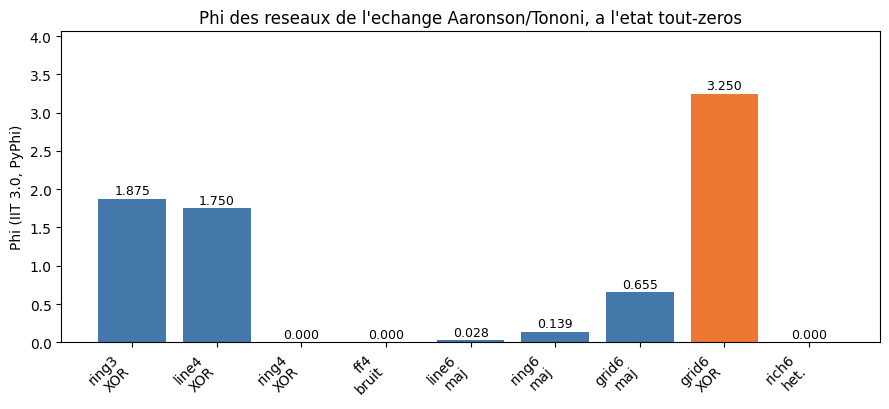

In [12]:
import matplotlib
import matplotlib.pyplot as plt

donnees = [
    ("ring3\nXOR", phi_ring3), ("line4\nXOR", phi_line4), ("ring4\nXOR", phi_ring4),
    ("ff4\nbruit", phi_ff4), ("line6\nmaj", phi_line6), ("ring6\nmaj", phi_ring6),
    ("grid6\nmaj", phi_grid6), ("grid6\nXOR", phi_grid6xor), ("rich6\nhet.", phi_rich6),
]

fig, ax = plt.subplots(figsize=(9, 4.2))
noms = [d[0] for d in donnees]
vals = [d[1] for d in donnees]
couleurs = ["#4477aa"] * 7 + ["#ee7733", "#009988"]
barres = ax.bar(noms, vals, color=couleurs)
for b, v in zip(barres, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Phi (IIT 3.0, PyPhi)")
ax.set_title("Phi des reseaux de l'echange Aaronson/Tononi, a l'etat tout-zeros")
ax.set_ylim(0, max(vals) * 1.25 if max(vals) > 0 else 0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Lecture des résultats n=6 — quatre lectures, sur valeurs mesurées.**

1. **L'objet XOR d'Aaronson porte le Φ maximal de la table.** La grille XOR (`grid6_xor`,
   Φ = 3,25) domine toutes les autres instances mesurées — l'intuition centrale de la
   construction du post (la parité intègre au maximum) se vérifie **aussi** en IIT 3.0,
   pas seulement en $\Phi_{DM}$. La nuance mesurée : l'effondrement GF(2) observé sur
   `ring4` est une propriété des topologies **bipartites régulières** (tous les nœuds de
   degré 2, cycle pair) — la grille 2×3, dont les nœuds médians ont **trois** voisins,
   échappe à cette décomposition et sature au contraire la mesure.
2. **La grille de Tononi mesure ce qu'elle annonce.** À portes majorité (non
   linéaires), la grille `grid6` développe un Φ strictement positif (0,655) à l'état
   tout éteint — le scénario exact de l'essai (« all gates off », sans E/S). La
   position assumée n'est pas un vœu : son instanciation mesurable existe et mesure
   positivement aux tailles accessibles.
3. **Le mur et la corde, en tendance.** Dans la famille majorité : ligne (0,028) <
   anneau (0,139) < grille (0,655) — rapport grille/ligne ≈ 24×. L'argument IV
   d'Aaronson (« pourquoi la corde 1D serait-elle moins consciente que le mur 2D ? »)
   suppose Φ(1D) petit face à Φ(2D) : la tendance mesurée à n=6 va dans ce sens, mais
   deux formes ne font pas la loi asymptotique √n — sobriété.
4. **Le contraste renversé.** `rich6` — portes hétérogènes (XOR, AND, OR, MAJ),
   connectivité irrégulière — mesure **zéro** à cet état. Le réseau « au comportement
   riche » est en bas du tableau, la grille triviale en haut. La dissociation que
   l'objection dénonce (intégration ≠ richesse comportementale) est donc **mesurée
   dans IIT 3.0 lui-même**, pas seulement dans la jambe $\Phi_{DM}$. Rappel de la
   leçon d'état de IIT-01 : Φ s'évalue relativement à un état — à l'état tout-zéros,
   les portes AND/OR ont des répertoires de cause faibles (leur sortie à 0 contraint
   peu leur passé), quand la parité contraint fortement dans les deux sens.

### 3.2 Sobriété : ce que cette jambe ne mesure pas

- **L'asymptotique.** La prédiction centrale (grille 1000×1000, Φ colossal) est hors
  d'atteinte : le calcul exact de Φ 3.0 explose combinatoirement au-delà de ~8 nœuds
  (déjà documenté dans IIT-02, section performance). Ce qui est mesuré ici : des Φ
  **exacts** à n ≤ 6, et la divergence XOR/majorité sur topologie identique.
- **La conscience.** Aucune jambe ne la mesure — ni §2 ni §3. Le statut de conscience
  de la grille est une **position** (Tononi l'assume, Aaronson la rejette sur
  paradigme-cases) ; ce notebook la cite avec ses deux auteurs, il ne l'évalue pas.
- **Le cervelet.** L'argument III (69 milliards de neurones, connexions sans
  latéralité) est un argument de littérature neuroscientifique — non instanciable
  ici, cité pour la complétude du dialogue.

***

<a id="sec4"></a>
## 4. Ce que l'échange a produit après

- **La relance Griffith.** Virgil Griffith — co-auteur de publications IIT et
  contributeur de l'écosystème PyPhi — a prolongé l'échange (p=1893, juin 2014,
  archivé au gisement) : le débat ne s'est pas refermé sur p=1823.
- **La fertilité pour l'outillage.** Les versions ultérieures de la théorie et de
  PyPhi (jusqu'à IIT 4.0 et ses distinctions/relations) ont continué de déplacer la
  définition de Φ — exactement le point II d'Aaronson (« que dire de toutes ces mises
  à jour ? »), auquel Tononi répond que la formulation évolue et que « les arguments
  mathématiques sont essentiels ». Les remerciements de son essai citent Mayner
  (auteur de PyPhi) et Hoel — l'échange vit littéralement dans l'outil.
- **Un test falsifiable proposé par Tononi.** Fin d'essai : ajouter du matériel
  non neuronal aux bonnes connexions pour **doubler l'étendue d'une grille corticale**
  contribuant à l'expérience de l'espace 2D — si le Φ croît sans expansion de
  l'expérience spatiale, « IIT would be in serious trouble ». Une théorie qui propose
  son propre banc d'échafaud mérite d'être citée comme telle.
- **La leçon de structure.** L'objection a fabriqué un **objet-banc d'essai** (le
  système à intégration maximale et comportement trivial) ; la réponse a **assumé la
  conséquence** plutôt que d'amender la définition. C'est le schéma d'un désaccord
  scientifique sain : une mesure, un contre-exemple, une position tenue des deux
  côtés, et des instruments (Φ_DM, PyPhi) qui permettent à un tiers de **refaire le
  calcul** — ce que ce notebook fait.

***


<a id="sec5"></a>
## 5. Exercices

### Exercice 1 : le contre-éclairage — identité et autres corps

La mise à jour (4) du post oppose la Vandermonde (toutes sous-matrices de rang plein)
à l'identité (inversible, Φ = 0). Vérifiez les deux affirmations sur **vos propres**
instances : reconstruisez `phi_dm` sur l'identité en n=12, puis sur une matrice de
**permutation** (inversible, une seule sortie par entrée). Que mesurez-vous, et pourquoi ?

**Indice** : `rang_mod_p` et `phi_dm` sont déjà définis. Une permutation :
`P = np.eye(n, dtype=int)[:, np.random.permutation(n)]` (fixez la graine pour la
reproductibilité).


In [13]:
# Exercice 1 : identite et permutation en n=12 -- que vaut leur Phi_DM ?
# TODO etudiant : construire I12 (identite) et P12 (permutation fixee),
# calculer phi_dm pour chacune, et expliquer le resultat en une phrase.
# Indice : res_I = phi_dm(np.identity(12, dtype=int), 1009)
# Indice : rng = np.random.default_rng(42); P = np.eye(12, dtype=int)[:, rng.permutation(12)]

resultat_ex1 = None  # TODO etudiant : remplacer par un dict {'identite': ..., 'permutation': ...}
if resultat_ex1 is not None:
    print(f"Resultat: {resultat_ex1}")
else:
    print("Exercice a completer")

Exercice a completer


### Exercice 2 : votre propre W — le hack à une autre échelle

Le post suppose n multiple de 4. Construisez W pour n=12, p=2003, et vérifiez :
(1) la valeur normalisée minimale vaut bien $\log_2 p$ ; (2) le Φ final vaut
$(n/2)\log_2 p$ ; (3) le rapport au contenu total reste 50 %. Puis **rompez** le
motif : répétez les lignes trois fois au lieu de deux (`matrice_W3`) — la valeur
normalisée du minimum change-t-elle ? Le Φ final ?

**Indice** : pour (3), écrire une variante qui empile chaque ligne de Vandermonde trois
fois — attention, n doit rester multiple de 3 pour que la matrice reste carrée.


In [14]:
# Exercice 2 : W a n=12, p=2003, puis la variante "lignes tripletees"
# TODO etudiant : verifier les trois points, puis construire matrice_W3 et comparer.
# Indice : res_W = phi_dm(matrice_W(12, 2003), 2003)
# Indice : attendu (1) log2(2003) ~ 10.97, (2) 6*log2(2003), (3) 50 %

resultat_ex2 = None  # TODO etudiant : {'W12': ..., 'W3': ...}
if resultat_ex2 is not None:
    print(f"Resultat: {resultat_ex2}")
else:
    print("Exercice a completer")

Exercice a completer


### Exercice 3 : la corde et le mur — fermer la boucle change-t-il Φ ?

L'argument IV oppose la ligne 1D à la grille 2D. Une question plus fine : à portes
**majorité** et n=5, que fait le passage **ligne → anneau** (fermer la chaîne) sur le
Φ d'IIT 3.0 ? Construisez `line5` et `ring5` (mêmes conventions que le §3 : COPY en
bout de ligne pour la ligne, MAJ ailleurs), mesurez à l'état tout-zéros, et comparez
à `line6`/`ring6` déjà mesurés.

**Questions** :
- Fermer la boucle augmente-t-il Φ à taille égale ?
- Le Φ mesuré dépend-il de l'état d'évaluation ? Testez un autre état atteignable
  (par exemple l'état tout-un — point fixe lui aussi pour ces portes).

**Indice** : réutiliser `build_network`, `voisins_ligne`, `voisins_anneau`,
`porte_de_voisinage` et `mesure_phi` (adapter le voisinage à n=5).


In [15]:
# Exercice 3 : line5 vs ring5 (portes majorite), Phi a deux etats
# TODO etudiant : construire les deux reseaux, mesurer Phi a (0,0,0,0,0) et (1,1,1,1,1)
# Indice : line5 = build_network([porte_de_voisinage(voisins_ligne(i, 5), MAJ) for i in range(5)])
# Indice : mesure_phi(net, "nom", etat=(1,)*5)

resultat_ex3 = None  # TODO etudiant : {(reseau, etat): phi, ...}
if resultat_ex3 is not None:
    print(f"Resultat: {resultat_ex3}")
else:
    print("Exercice a completer")

Exercice a completer


### Exercice 4 : la grille bruitée — le déterminisme est-il nécessaire ?

La grille de Tononi est décrite déterministe (« fire if the majority of the inputs are
on »), mais IIT ne requiert pas le déterminisme. Bruitez `grid6` : chaque porte passe
de MAJ à une version probabiliste (sortie 1 avec probabilité 0.9 si majorité, sinon
0.1). Mesurez le Φ à l'état tout-zéros et comparez à `grid6` déterministe.

**Question** : le Φ monte-t-il, descend-il, ou reste-t-il comparable — et pourquoi la
structure cause-effet d'une porte probabiliste diffère-t-elle de sa version déterministe ?

**Indice** : `build_network` accepte des fonctions qui rendent une probabilité
(cf. `bruit` du feedforward). Définir `MAJ_BRUITEE = lambda s: 0.9 if MAJ(s) else 0.1`.


In [16]:
# Exercice 4 : grid6 bruitee (p=0.9) vs grid6 deterministe
# TODO etudiant : construire grid6_bruitee et mesurer son Phi a l'etat tout-zeros
# Indice : MAJ_BRUITEE = lambda s: 0.9 if MAJ(s) else 0.1
# Indice : grid6_b = build_network([porte_de_voisinage(voisins_grille(i), MAJ_BRUITEE) for i in range(6)])

resultat_ex4 = None  # TODO etudiant : phi de la grille bruitee
if resultat_ex4 is not None:
    print(f"Resultat: {resultat_ex4}")
else:
    print("Exercice a completer")

Exercice a completer


<a id="sec6"></a>
## 6. Conclusion

Ce notebook a exécuté l'objet au centre de l'échange Aaronson/Tononi de mai 2014, des
deux côtés de la frontière entre formalisations :

| Ce qu'on a fait | Jambe | Résultat mesuré |
|-----------------|-------|-----------------|
| Reproduit la construction du post | $\Phi_{DM}$ (§2) | Vandermonde : égalité normalisée partout → Φ **indéfini** ; W : minimum unique, Φ = $(n/2)\log_2 p$ = 50 % du contenu total ; identité : Φ = 0 ; croissance linéaire |
| Instancié la grille de la réponse | Φ 3.0 / PyPhi (§3) | grille majorité à l'état tout-zéros : Φ = 0,655 (le scénario assumé mesure ce qu'il annonce) ; ligne < anneau < grille en famille majorité ; feedforward : Φ = 0 ; anneau XOR bipartite : Φ = 0 |
| Mesuré les deux cadrages l'un contre l'autre | les deux | la grille **XOR** porte le Φ **maximal** de la table (3,25) — dans les DEUX formalisations, la parité intègre au maximum ; le réseau « riche » hétérogène mesure 0 à cet état |

**Le fil conceptuel.** L'objection d'Aaronson fabrique un objet-banc d'essai — intégration
maximale, comportement trivial — et montre qu'il sature la mesure visée ; la réponse de
Tononi assume la conséquence au lieu d'amender la définition, et propose même son propre
test falsifiable (doubler une grille corticale). Entre les deux, la formalisation a bougé
(2.0 → 3.0 → 4.0), et la saturation ne s'attache pas aux mêmes objets : la matrice W de
l'objection n'a pas de contrepartie PyPhi, l'anneau XOR pair s'effondre en 3.0 quand la
grille 2×3 la sature, et le réseau hétérogène « riche » mesure zéro à l'état évalué. Ce
qu'aucune jambe ne mesure : la conscience.
C'est la question de l'échange, elle reste ouverte, et c'est exactement pourquoi cet
échange reste le banc d'essai de référence pour toute théorie qui prétend la quantifier.

> **À retenir** : une théorie quantitative de la conscience se teste d'abord à ses
> **contre-exemples calculables**. L'IIT a eu l'objection la plus calculable de
> l'histoire du champ — et la réponse la plus assumée. Mesurer, citer les deux positions
> avec leurs grades, et laisser la question ouverte : c'est la discipline de ce notebook.

### Pour aller plus loin

- Le chaînon manquant calculatoire : une **borne inférieure d'intégration prouvée**
  formellement (Lean) — terrain préparé par les définitions posées ici, hors périmètre
  de ce notebook (suivi nommé dans l'issue #17378).
- Les raffinements IIT 4.0 (distinctions/relations) et leurs instruments — voir
  [IIT-2 : Sujets avancés](./IIT-02-AdvancedTopics.ipynb) section 8.

### Ressources

**Sources de l'échange** (archivées dans le gisement partagé
`G:\Mon Drive\MyIA\IA\Bibliographie IA\Consciousness\` — jamais dans le dépôt) :

- Aaronson, *Why I Am Not An Integrated Information Theorist (or, The Unconscious Expander)*,
  scottaaronson.blog ?p=1799, 21 mai 2014 — l'objection et sa construction.
- Tononi, *Why Scott should stare at a blank wall and reconsider (or, the conscious grid)*,
  essai du 28 mai 2014 (tononi.docx, scottaaronson.com) — la réponse qui assume.
- Aaronson, *Giulio Tononi and Me: A Phi-nal Exchange*, scottaaronson.blog ?p=1823,
  30 mai 2014 — les quatre contre-arguments.
- Aaronson, *IIT, Virgil Griffith opines*, scottaaronson.blog ?p=1893 — la relance.
- Aaronson, *The Ghost in the Quantum Turing Machine*, 2013 (85 p.) — le texte fondateur
  dont la section IIT précède l'objection.

**Outillage** :

- [Documentation PyPhi](https://pyphi.readthedocs.io/en/stable/) — moteur IIT 3.0.
- Mayner et al. (2018), *PyPhi: A toolbox for integrated information theory*,
  PLOS Computational Biology 14(7): e1006343.
- Oizumi, Albantakis, Tononi (2014), *From the Phenomenology to the Mechanisms of
  Consciousness* — la formulation 3.0 que Tononi oppose à l'objection.

**Fin du notebook**. Merci pour votre attention !
